<a href="https://colab.research.google.com/github/SergeiVKalinin/MSE_Fall_2025/blob/main/Module%207/Homework_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem 1. Simpson Paradox

Two hotels, Aurora and Beacon, operate in a city with strong seasonality. You’re given counts of 5-star reviews out of total stays for two periods. Assume each row is independent data collected over the same length of time in that season.

Season	- Hotel	- 5-star reviews	- Total stays

Peak	 - Aurora	  - 19	   -  20

Peak	  - Beacon	 -  188	   - 200

Off-season- 	Aurora	 - 120	 - 200

Off-season	- Beacon	- 11	- 20




Within-season comparison.
- Compute each hotel’s 5-star rate in Peak.
- Compute each hotel’s 5-star rate in Off-season.
- Which hotel has the higher rate within each season?

Overall comparison. Pool the seasons (sum numerators and denominators by hotel).
- Compute each hotel’s overall 5-star rate.
- Which hotel looks better overall?

Explain the paradox.
Why does the overall conclusion contradict the within-season conclusions?
Identify the lurking variable and describe how it changes the weighting of observations.

Answer:

Avoiding the pitfall.
Give two ways an analyst could avoid being misled here (e.g., model design or reporting practice).

Answer:

# Problem 2. Causal Discovery

Here, we analyze the class problem on causal discovery and policy making in the temperature - ice cream - accidents scenario.

In [1]:
!pip install gCastle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.4/214.4 kB 5.1 MB/s eta 0:00:00


Sample correlations (observational):
             IceCream  Accidents  Temperature
IceCream        1.000      0.646        0.848
Accidents       0.646      1.000        0.817
Temperature     0.848      0.817        1.000


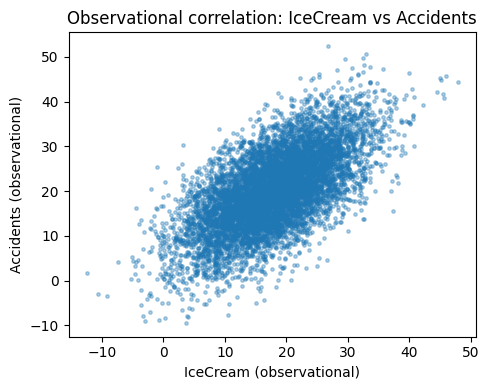

In [2]:
# ============================================================
# IceCream–Accidents–Temperature: Simpson's Paradox Generator
# + Correlations, gCastle (PC/NOTEARS), and Policy Estimation
# ============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# gCastle algorithms
from castle.algorithms import PC, Notears

# -------------------------------
# 1) Data-generating mechanism
# -------------------------------
def generate_data(n=5000, seed=42,
                  a_TI=0.9,          # T -> IceCream strength (positive)
                  b_TA=1.2,          # T -> Accidents strength (positive, strong)
                  c_IA=-0.2,         # IceCream -> Accidents strength (negative!)
                  sigma_T=7.0,       # Temperature std
                  sigma_I=4.0,       # noise in IceCream
                  sigma_A=5.0):      # noise in Accidents
    """
    Structural equations (observational world):
      T ~ Normal(mu_T, sigma_T)
      I = a_TI * T + eps_I
      A = b_TA * T + c_IA * I + eps_A
    Choose b_TA large and |c_IA| modest so corr(I, A) > 0 observationally.
    """
    rng = np.random.default_rng(seed)
    T = rng.normal(loc=20.0, scale=sigma_T, size=n)
    I = a_TI * T + rng.normal(0, sigma_I, size=n)
    A = b_TA * T + c_IA * I + rng.normal(0, sigma_A, size=n)

    df = pd.DataFrame({"Temperature": T, "IceCream": I, "Accidents": A})
    return df

# ---------------------------------------
# 3) Make observational data + sanity
# ---------------------------------------
df = generate_data(n=8000, seed=1)
print("Sample correlations (observational):")
print(df[["IceCream", "Accidents", "Temperature"]].corr().round(3))

# Expect: corr(IceCream, Accidents) > 0 (spurious due to Temperature)

# Quick scatter to show positive correlation observationally
plt.figure(figsize=(5,4))
plt.scatter(df["IceCream"], df["Accidents"], s=6, alpha=0.35)
plt.xlabel("IceCream (observational)")
plt.ylabel("Accidents (observational)")
plt.title("Observational correlation: IceCream vs Accidents")
plt.tight_layout(); plt.show()


1. Estimate the direct correlation between accidents and icecream consumption. How would the accident rate change if ice cream sales are forbidden?

2. Use gCastle to analyze the causal model. Plot causal graph learned from data.

3. Predict the interventional effect of changes in ice cream sales on accidents.

# Problem 3. Front door criterion

Here, we analyze the class example of the GPS use effect on memory, mediated by the hypotalamus volume.

In [3]:
# ===============================
# Front-door example: GPS → Hypothalamus → Memory
# with hidden confounder U between GPS and Memory
# ===============================

# (Colab) installs if you want to try structure learners:
# !pip install -q gcastle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# ---------- 1) Data-generating process ----------
# U -> X and U -> Y (hidden confounding)
# X -> M -> Y (front-door mediator)
# No direct X -> Y

def generate_observational(n=6000, seed=0,
                           a=1.2,     # U -> X
                           b=-0.4,    # X -> M  (negative: more GPS, less volume)
                           c= 0.8,    # M -> Y  (positive: more volume, better memory)
                           d= 2.0,    # U -> Y  (confounding makes corr(X,Y) > 0)
                           sx=2.0, sm=1.0, sy=1.0):
    rng = np.random.default_rng(seed)
    U = rng.normal(size=n)
    X = a*U + rng.normal(scale=sx, size=n)
    M = b*X + rng.normal(scale=sm, size=n)
    Y = c*M + d*U + rng.normal(scale=sy, size=n)
    df = pd.DataFrame({"GPS_use": X, "HypothalamusVol": M, "Memory": Y})
    df.attrs["true_effect_X_to_Y"] = b * c  # ground truth via mediator
    return df


df = generate_observational()

df.head()

,GPS_use,HypothalamusVol,Memory
0,-2.552853,1.342615,1.417661
1,-1.483670,-0.218116,-0.229590
2,0.604907,0.206129,-1.242597
3,1.884722,-2.321043,-1.170776
4,2.565384,-2.115427,-3.687010


In [4]:
print("Correlation matrix (observational):")
print(df.corr().round(3))  # Expect corr(GPS_use, Memory) > 0 due to confounding

Correlation matrix (observational):
                 GPS_use  HypothalamusVol  Memory
GPS_use            1.000           -0.690   0.144
HypothalamusVol   -0.690            1.000   0.147
Memory             0.144            0.147   1.000


Explore naive relationship between GPS use and memory

Construct the causal model. Predict the effect of intervention (e.g. policy change on GPS use) on memory.

# Problem 4. Instrumental variables

In this data set, we have (simulated) data on intragrain conductivity of ceramics depending on dopant level. Note that dopants can be both within grains and segregate at the grain boundary. We want to estimate the causal effect of activated dopant level inside grains (Activation, X) on intragrain conductivity (Conductivity, Y).

- Directly regressing Y on X is biased because hidden processing/chemistry factors (U) affect both activation and conductivity.

- We will use microstructure as instruments (Z): things like grain-boundary density, porosity, fraction of low-angle GBs, twin density. These are expected to influence activation (via segregation/kinetics) but, because we measure conductivity inside grain cores, they should have no direct effect on Y—only through X.

- The target causal graph is as following:
microstructure (Z) → Activation (X) → Conductivity (Y), with a hidden confounder U → {X, Y}.

The IV logic identifies the effect of X→Y using Z, provided:

- Relevance: Z changes X (check).

- Exclusion: Z affects Y only via X (we conclude it from physics model).

- Independence: Z is not related to the unobserved U that also affects Y (use exogenous processing variation).

Tip: grain_size and gb_density are ~inverses; don’t include both in the same regression.

In [5]:
!pip install -q gcastle linearmodels statsmodels scikit-learn pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.1 MB/s eta 0:00:00


In [6]:
# ================================
# IV demo (materials): microstructure instruments for dopant activation
# ================================
#

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Optional: IV with proper SEs
from linearmodels.iv import IV2SLS
import statsmodels.api as sm

# gCastle (causal discovery)
from castle.algorithms import PC, Notears
# Try FCI if available (robust to latents); else skip
try:
    from castle.algorithms import FCI
    HAS_FCI = True
except Exception:
    HAS_FCI = False

rng = np.random.default_rng(7)

# ------------------------------
# 1) Data-generating process
# ------------------------------
def synthesize(n=4000, seed=7):
    rng = np.random.default_rng(seed)
    # Instruments (microstructure), independent of U
    grain_size = np.exp(rng.normal(np.log(12), 0.35, size=n))     # μm, log-normal
    gb_density = 1.0 / grain_size                                 # proxy for GB area density
    porosity   = np.clip(rng.normal(0.06, 0.02, size=n), 0.0, 0.2)
    f_LAGB     = np.clip(rng.beta(4, 6, size=n), 0.0, 1.0)        # fraction of low-angle GBs
    twin_den   = np.clip(rng.normal(0.15, 0.05, size=n), 0.0, 0.5)

    # Hidden confounder (anneal chemistry/history)
    U = rng.normal(0, 1, size=n)

    # Structural equations:
    # X = activation inside grains (endogenous treatment)
    # Y = intragrain conductivity (outcome)
    # No direct Z -> Y (exclusion: measured in grain interior)
    # Relevance: Z -> X; Endogeneity: U -> X and U -> Y
    eps_x = rng.normal(0, 0.6, size=n)
    eps_y = rng.normal(0, 1.5, size=n)

    a1, a2, a3, a4 = 1.3, 1.1, 0.8, 0.6        # Z -> X (positive on gb_density/porosity/LAGB/twins lowers activation if sign-negative below)
    beta_u = 1.2                                # U -> X
    # Let higher gb_density/porosity/LAGB/twins REDUCE activation:
    X = ( -a1*gb_density - a2*porosity - a3*f_LAGB - a4*twin_den
          + beta_u*U + eps_x )

    gamma = 2.0   # causal effect X -> Y (>0)
    delta = 1.7   # U -> Y
    Y = gamma*X + delta*U + eps_y

    df = pd.DataFrame({
        "grain_size": grain_size,
        "gb_density": gb_density,
        "porosity": porosity,
        "f_LAGB": f_LAGB,
        "twin_density": twin_den,
        "Activation": X,
        "Conductivity": Y
    })
    df.attrs["true_beta"] = gamma
    return df

df = synthesize()

print("Head:\n", df.head(), "\n")
print("Correlations (observational):\n", df[["Activation","Conductivity","gb_density","porosity","f_LAGB","twin_density"]].corr().round(3), "\n")

Head:
    grain_size  gb_density  porosity    f_LAGB  twin_density  Activation  \
0   12.005168    0.083297  0.075014  0.412181      0.172067   -0.607884   
1   13.322677    0.075060  0.081395  0.194500      0.165449    0.359305   
2   10.902132    0.091725  0.040202  0.548336      0.172076    1.131761   
3    8.786351    0.113813  0.085350  0.093449      0.129818    0.566795   
4   10.234577    0.097708  0.050512  0.425677      0.046780   -2.419771   

   Conductivity  
0     -6.615208  
1      0.458457  
2      5.364223  
3      2.898671  
4     -8.639474   

Correlations (observational):
               Activation  Conductivity  gb_density  porosity  f_LAGB  \
Activation         1.000         0.929      -0.038    -0.043  -0.101   
Conductivity       0.929         1.000      -0.033    -0.036  -0.075   
gb_density        -0.038        -0.033       1.000     0.004   0.009   
porosity          -0.043        -0.036       0.004     1.000  -0.008   
f_LAGB            -0.101        -0.075   

1. Exploratory stage. Build summary stats and a correlation matrix for all columns. Construct scatterplots for:
- Activation vs Conductivity
- Each instrument (gb_density, porosity, f_LAGB, twin_density, or grain_size) vs Activation (relevance check).



2) Naive vs. IV

- Naive OLS: Conductivity ~ Activation. Report coeffficent analysis and one sentence on why it can be biased.

- First stage: Activation ~ chosen instruments (≥2 from the set; avoid grain_size+gb_density together).

- IV (2SLS): Effect of Activation on Conductivity using your instrument set. Report coef, robust SE, and 95% CI.



3. Causal effect analysis:

- State your best IV estimate of causal effect of activation on conductivity

- Estimate what will happen if activation rises by +0.5 and predicted change in Conductivity


4. gCastle check

- Standardize variables; run PC on
{grain_size, gb_density, porosity, f_LAGB, twin_density, Activation, Conductivity}.

- Show the DAG (diagram or adjacency table).

4) gCastle check

- Run NOTEARS and show the weighted adjacency; note edges instruments → Activation and Activation → Conductivity.

Do these graphs broadly agree with the IV story (relevance, no direct microstructure → Conductivity)? Mention any ambiguous/spurious edges.

Answer: